In [1]:
!pip install pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 15.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 12.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 KB 11.9 MB/s eta 0:00:00a 0:00:01


In [2]:
import pandas as pd

In [3]:
row1=["kim", 32]
row2=["park", 25]
row3=["lee", 27]

colNames=["name","age"]

df1=pd.DataFrame([row1,row2,row3],columns=colNames)
print(df1)

   name  age
0   kim   32
1  park   25
2   lee   27


In [4]:
from pyspark.sql import SparkSession

In [5]:
spark = SparkSession.builder.appName("Spark Study").getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/16 07:42:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [6]:
spDf=spark.createDataFrame([row1,row2,row3],schema=colNames)

In [9]:
spDf.show()

+----+---+
|name|age|
+----+---+
| kim| 32|
|park| 25|
| lee| 27|
+----+---+



In [10]:
spDf2=spark.createDataFrame(df1)
spDf2.show()

+----+---+
|name|age|
+----+---+
| kim| 32|
|park| 25|
| lee| 27|
+----+---+



#### pandas의 DataFrame이랑 spark의 DataFrame이랑 같게 만들어짐.
#### 둘중에 아무거나 사용해도 됨!

In [11]:
print(type(df1), type(spDf), type(spDf2))

<class 'pandas.core.frame.DataFrame'> <class 'pyspark.sql.classic.dataframe.DataFrame'> <class 'pyspark.sql.classic.dataframe.DataFrame'>


In [14]:
panDf = spDf.toPandas()
print(panDf, type(panDf))

   name  age
0   kim   32
1  park   25
2   lee   27 <class 'pandas.core.frame.DataFrame'>


In [15]:
print(spDf)

DataFrame[name: string, age: bigint]


`spark.createDataFrame`: pandas의 dataframe을 spark의 dataframe으로 바꿈  
`.toPandas()`: 반대로 spark를 pandas형태로 바꿈

In [16]:
spDf.createOrReplaceTempView("s_table")
print(spDf)

DataFrame[name: string, age: bigint]


`TempView`: 임시 뷰 생성  
`TempTable`: 임시 테이블 생성  
스파크에서 두개는 같은 의미로 분류되므로 둘중에 아무거나 사용해도 됨  
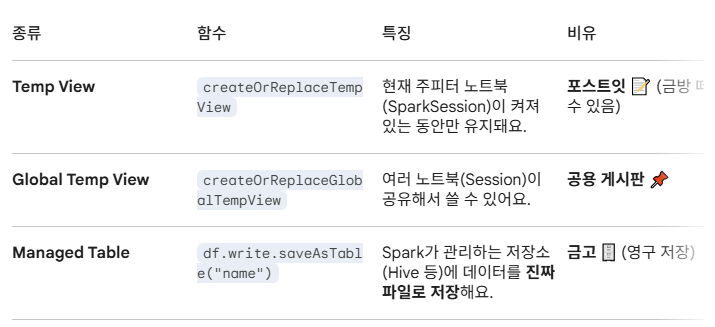

In [17]:
sql1 ="""
select name, age from s_table where age>30;
"""
result = spark.sql(sql1)

In [18]:
result.show()

+----+---+
|name|age|
+----+---+
| kim| 32|
+----+---+



17-18: 비정형데이터를 정형데이터처럼 사용하는 방법.  
table을 생성해서 원하는 데이터만 뽑아 사용할 수 있음  
spark는 자체적으로 sql()함수를 가지고있어서 MySQL처럼 sql문만 알면 사용할 수 있음

In [19]:
result2 = spDf.filter(spDf.age >= 30)
result2.show()

+----+---+
|name|age|
+----+---+
| kim| 32|
+----+---+



단순히 조건별 select만 하는거면 filter처리해도 됨  
조건이 복잡해지거나 insert 등을 사용할 때는 sql 사용

### 테이블에 컬럼 추가하기

In [20]:
from pyspark.sql.functions import expr

In [21]:
result3 = spDf.withColumn("newCol",expr("case when age > 30 then 'over 30' else 'lower 30' end"))
result3.show()

+----+---+--------+
|name|age|  newCol|
+----+---+--------+
| kim| 32| over 30|
|park| 25|lower 30|
| lee| 27|lower 30|
+----+---+--------+



- .withColumn("컬럼명", expr(case문으로 설명추가))
- .catalog.listTables(): 테이블 정보 꺼내기
- .catalog.dropTempView("s_table"): 드롭
    - 이걸로 테이블 날려도 원본 데이터는 남아있음 ->> 그래서 rdd.collect()해보면 새로만든 newCol은 없음

In [25]:
spark.catalog.listTables()

[]

In [24]:
spark.catalog.dropTempView("s_table")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


True

In [27]:
rdd = spDf.rdd
print(rdd)
print(type(rdd))

MapPartitionsRDD[48] at javaToPython at NativeMethodAccessorImpl.java:0
<class 'pyspark.core.rdd.RDD'>


In [28]:
rdd.collect()

[Row(name='kim', age=32), Row(name='park', age=25), Row(name='lee', age=27)]

In [29]:
cols = spDf.columns

In [30]:
print(cols)

['name', 'age']


In [31]:
nameCol = cols.index("name")
print(nameCol)

0


In [32]:
ageCol = cols.index("age")
print(ageCol)

1


In [34]:
result = rdd.filter(lambda x: x[nameCol] == 'kim')
result.collect()

[Row(name='kim', age=32)]

In [36]:
result2 = rdd.filter(lambda x: x[ageCol] < 30)
result2.collect()

[Row(name='park', age=25), Row(name='lee', age=27)]

### 위 방식과 다르게 새 컬럼 만들기 + 기존 값 교체

In [37]:
def newCol(x):
    oName = x.name
    oAge = x.age
    name = oName+"_sir"
    age = oAge*10
    newCol = f"{name} {age}"
    return (name, age, newCol)

In [38]:
result = rdd.map(lambda x: newCol(x))
result.collect()

[('kim_sir', 320, 'kim_sir 320'),
 ('park_sir', 250, 'park_sir 250'),
 ('lee_sir', 270, 'lee_sir 270')]